In [ ]:
# 0. Preparación de ambientes necesarios

# Importar librerias
import pandas as pd
import xarray as xr
import numpy as np

import os
import errno
import geopandas as gpd
import seaborn as sns


import shapely
from shapely.geometry import shape, Polygon, Point, MultiPoint, box, LineString

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import cartopy
from cartopy import config
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader as sf
import cartopy.feature as cfeature


from mpl_toolkits.axes_grid1 import make_axes_locatable


from cmcrameri import cm

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from cmcrameri import cm as ccm

In [5]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = cwd

SRC_DIR = ROOT / "src"
DATA_DIR_RAW = ROOT / "data" / "raw"
OUTPUT_DIR = ROOT / "outputs" / "figures"

for path in [ROOT, SRC_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT      : {ROOT}")
print(f"SRC_DIR   : {SRC_DIR}")
print(f"DATA_DIR_RAW : {DATA_DIR_RAW}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


ROOT      : /mnt/c/Users/adolf/Documents/GitHub/tc-size-rainfall-figures
SRC_DIR   : /mnt/c/Users/adolf/Documents/GitHub/tc-size-rainfall-figures/src
DATA_DIR_RAW : /mnt/c/Users/adolf/Documents/GitHub/tc-size-rainfall-figures/data/raw
OUTPUT_DIR: /mnt/c/Users/adolf/Documents/GitHub/tc-size-rainfall-figures/outputs/figures


In [2]:
columns_name = [   'dd',    'mm',    'yy',    'hh',   'lat',   'lon',   'MWS',  'CPSL',
                    'RNE',   'RNW',   'RSW',   'RSE',    'Rp',     'A',     'D',     'S',
                    'CT', 'R_max',       0,       1,       2,       3,       4,       5,
                        6,       7,       8,       9,      10,      11,      12,      13,
                        14,      15,      16,      17,      18,      19,      20,      21,
                        22,      23,      24,      25,      26,      27,      28,      29,
                        30,      31,      32,      33,      34,      35,      36,      37,
                        38,      39]

In [9]:
DATA_DIR_RAW / 'na_ne50.dat'

PosixPath('/mnt/c/Users/adolf/Documents/GitHub/tc-size-rainfall-figures/data/raw/na_ne50.dat')

In [13]:
ep_ani50 = pd.read_table(DATA_DIR_RAW / 'EP_anillos.dat', names=columns_name, index_col=False )
na_ani50 = pd.read_table(DATA_DIR_RAW /'NA_anillos.dat', names=columns_name, index_col=False )

promNA, promEP = na_ani50, ep_ani50
rrNA = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain': promNA.loc[:, 0:39].sum() / len(promNA),'basin': 'NA'})
rrEP = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':promEP.loc[:, 0:39].sum()/len(promEP), 'basin': 'EP'})

In [10]:

nane= pd.read_table(DATA_DIR_RAW / 'na_ne50.dat', names=columns_name, index_col=False )
nano= pd.read_table(DATA_DIR_RAW / 'na_no50.dat', names=columns_name, index_col=False )
naso= pd.read_table(DATA_DIR_RAW / 'na_so50.dat', names=columns_name, index_col=False )
nase= pd.read_table(DATA_DIR_RAW / 'na_se50.dat', names=columns_name, index_col=False )

epne= pd.read_table(DATA_DIR_RAW / 'ep_ne50.dat', names=columns_name, index_col=False )
epno= pd.read_table(DATA_DIR_RAW / 'ep_no50.dat', names=columns_name, index_col=False )
epso= pd.read_table(DATA_DIR_RAW / 'ep_so50.dat', names=columns_name, index_col=False )
epse= pd.read_table(DATA_DIR_RAW / 'ep_se50.dat', names=columns_name, index_col=False )

rrne = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':nane.loc[:, 0:39].sum()/len(nane), 'basin': 'RNE'})
rrno = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':nano.loc[:, 0:39].sum()/len(nano), 'basin': 'RNW'})
rrso = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':naso.loc[:, 0:39].sum()/len(naso), 'basin': 'RSW'})
rrse = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':nase.loc[:, 0:39].sum()/len(nase), 'basin': 'RSE'})
NAQ  =  pd.concat([rrne,rrno,rrso,rrse],axis=0).reset_index(drop=True)

rrne = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':epne.loc[:, 0:39].sum()/len(epne), 'basin': 'RNE'})
rrno = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':epno.loc[:, 0:39].sum()/len(epno), 'basin': 'RNW'})
rrso = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':epso.loc[:, 0:39].sum()/len(epso), 'basin': 'RSW'})
rrse = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':epse.loc[:, 0:39].sum()/len(epse), 'basin': 'RSE'})
EPQ  =  pd.concat([rrne,rrno,rrso,rrse],axis=0).reset_index(drop=True)

In [14]:
def raincat(ep_ani50):
    DT = ep_ani50.loc[ep_ani50.MWS <= 63]
    TT = ep_ani50.loc[(ep_ani50.MWS > 63)&(ep_ani50.MWS <= 118)]
    MI = ep_ani50.loc[(ep_ani50.MWS > 118)&(ep_ani50.MWS <= 178)]
    MA = ep_ani50.loc[(ep_ani50.MWS > 178)]
    return DT,TT,MI,MA

DT_EP,TT_EP,MI_EP,MA_EP = raincat(ep_ani50)
DT_NA,TT_NA,MI_NA,MA_NA = raincat(na_ani50)

In [15]:
def cat(DT_NA,TT_NA,MI_NA,MA_NA):
    nadt = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':DT_NA.loc[:, 0:39].sum()/len(DT_NA), 'basin': 'TD'})
    natt = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':TT_NA.loc[:, 0:39].sum()/len(TT_NA), 'basin': 'TS'})
    nami = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':MI_NA.loc[:, 0:39].sum()/len(MI_NA), 'basin': 'MIN HUR'})
    nama = pd.DataFrame({'x': np.arange(0,2001,50)[:-1],'rain':MA_NA.loc[:, 0:39].sum()/len(MA_NA), 'basin': 'MAJ HUR'})
    NAcat  =  pd.concat([nadt,natt,nami,nama],axis=0).reset_index(drop=True)
    return NAcat

In [16]:
NAcat = cat(DT_NA,TT_NA,MI_NA,MA_NA)
EPcat = cat(DT_EP,TT_EP,MI_EP,MA_EP)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


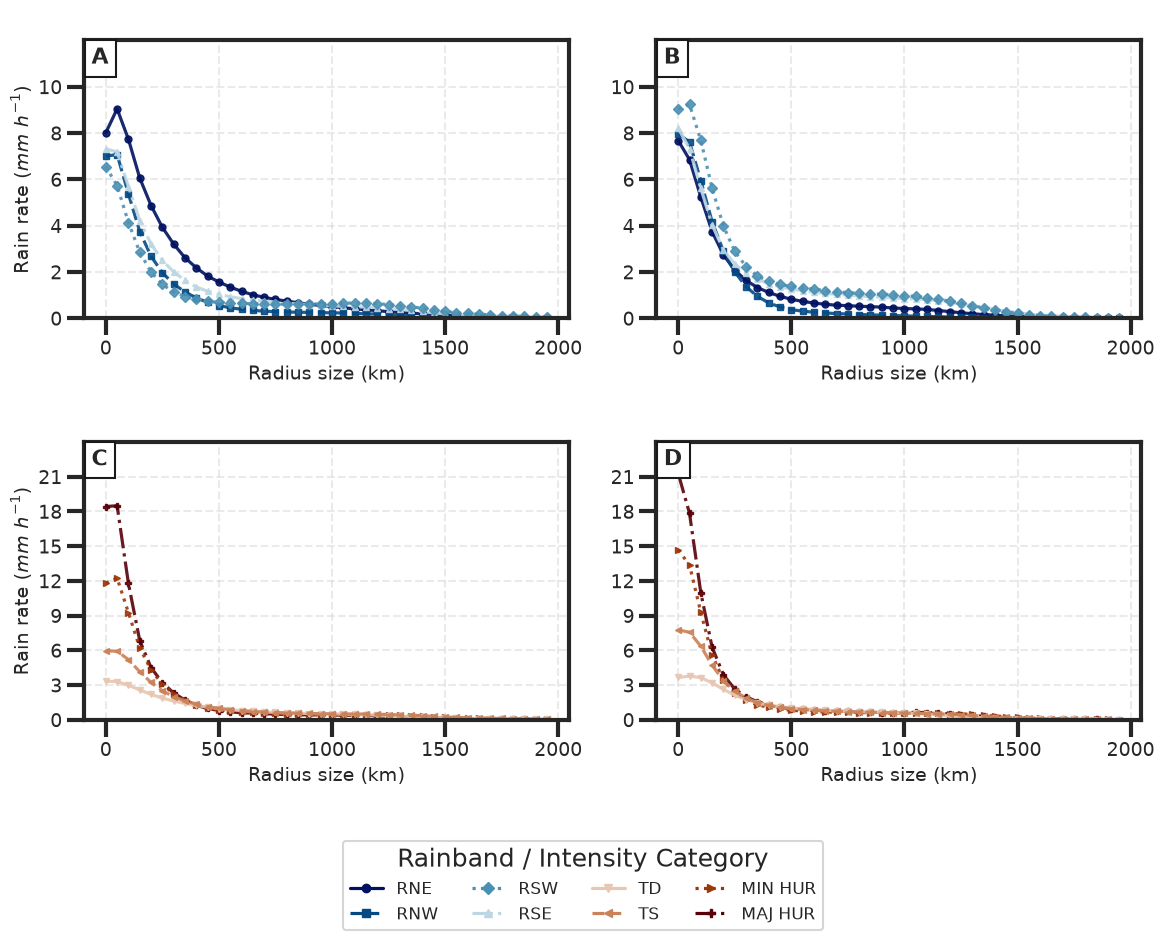

In [ ]:
# ================================
# Configuración general
# ================================
custom_params = {
    "axes.spines.right": True,
    "axes.spines.top": True,
    "axes.spines.left": True,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.titlesize": 16
}
sns.set_theme(style="ticks", context="talk", rc=custom_params)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

datasets = [
    ("A", " ", "Rain rate ($mm$ $h^{-1}$)", NAQ),
    ("B", " ", "", EPQ),
    ("C", " ", "Rain rate ($mm$ $h^{-1}$)", NAcat),
    ("D", " ", "", EPcat)
]

panel_labels = ["A", "B", "C", "D"]
x_txt, y_txt = 0.016, 0.975
# ================================
# 1️⃣ Definir orden deseado de la leyenda
# ================================
legend_order = ["RNE", "RNW", "RSW", "RSE", "TD", "TS", "MIN HUR", "MAJ HUR"]

# ================================
# 2️⃣ Crear lista de todas las series presentes
# ================================
all_basins = set()
for _, _, _, df in datasets:
    all_basins.update(df["basin"].unique())

# Filtramos solo las que realmente existen en los datos y las ordenamos según nuestro criterio
ordered_basins = [b for b in legend_order if b in all_basins]

# ================================
# 3️⃣ Crear estilos con Crameri (colores perceptuales)
# ================================
palette = ccm.vik(np.linspace(0, 1, len(ordered_basins)))  # puedes usar 'batlowS', 'roma', 'vik', etc.
linestyles = ["-", "--", ":", "-."]
markers = ["o", "s", "D", "^", "v", "<", ">", "P"]

styles = {}
for i, basin_name in enumerate(ordered_basins):
    styles[basin_name] = {
        "color": palette[i],
        "linestyle": linestyles[i % len(linestyles)],
        "marker": markers[i % len(markers)]
    }

# ================================
# 4️⃣ Graficar cada subplot
# ================================
for i, (ax, (label, title, ylabel, df)) in enumerate(zip(axes, datasets)):
    ax.set_title(title, pad=10)
    ax.set_xlabel("Radius size (km)")
    ax.set_ylabel(ylabel)
    # === 2. Luego configuramos el eje Y ===
    if i < 2:  # fila superior
        ax.set_ylim(0, 12)  # ✅ fija el rango
        ax.set_yticks(np.arange(0, 11, 2))  # ✅ define los ticks
    else:  # fila inferior
        ax.set_ylim(0, 24)  # ✅ rango distinto
        ax.set_yticks(np.arange(0, 23, 3))  # ✅ ticks distintos


    ax.grid(True, linestyle='--', alpha=0.4)

    for spine in ax.spines.values():
        spine.set_linewidth(3)
    ax.tick_params(axis="both", which="both", width=3, size=12, labelsize=14)

    # Etiqueta con recuadro en cada panel
    ax.text(
        x_txt, y_txt,
        rf'$\mathbf{{{label}}}$',
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(facecolor='w', edgecolor='k', pad=5.0),
        zorder=5
    )

    # Dibujar cada serie con el estilo definido
    for basin_name, group in df.groupby("basin"):
        if basin_name not in styles:
            continue
        style = styles[basin_name]
        ax.plot(
            group["x"],
            group["rain"],
            label=basin_name,
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=5,
            linewidth=2.3,
            alpha=0.9
        )

# ================================
# 5️⃣ Crear leyenda global ordenada
# ================================
legend_handles = [
    Line2D(
        [0], [0],
        color=styles[name]["color"],
        linestyle=styles[name]["linestyle"],
        marker=styles[name]["marker"],
        label=name,
        markersize=6,
        linewidth=2.3
    )
    for name in ordered_basins
]

fig.legend(
    handles=legend_handles,
    title="Rainband / Intensity Category",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.1),
    ncol=4,
    frameon=True
)

# ================================
# Ajustes finales
# ================================
plt.tight_layout(rect=[0, 0.12, 1, 0.95])

fig.savefig(OUTPUT_DIR / 'figures_02.eps', dpi=300, bbox_inches='tight')
plt.show()
